In [16]:
# Restore all previously stored variables
%store -r plots_dir hygrolon_area c_hygrolon n_hygrolon isopod_c_n_ratio isopod_c isopod_n springtail_c_n_ratio springtail_c springtail_n 
%store -r moss_c_n_ratio moss_c moss_n

no stored variable or alias hygrolon_area


In [2]:
# Import the below libraries:
"""For faster loading, consider importing the libraries in separate cells."""
# To create reproducible file paths
import os # To interact with the operating system
from pathlib import Path # To create Path objects
import pathlib # To access the object-oriented library for paths

# For scientific computing
import numpy as np # To work with arrays
from scipy.integrate import odeint # To solve ordinary differential equations (ODEs)

# For visualization and interactive plotting
import matplotlib.pyplot as plt # To import the Pyplot module

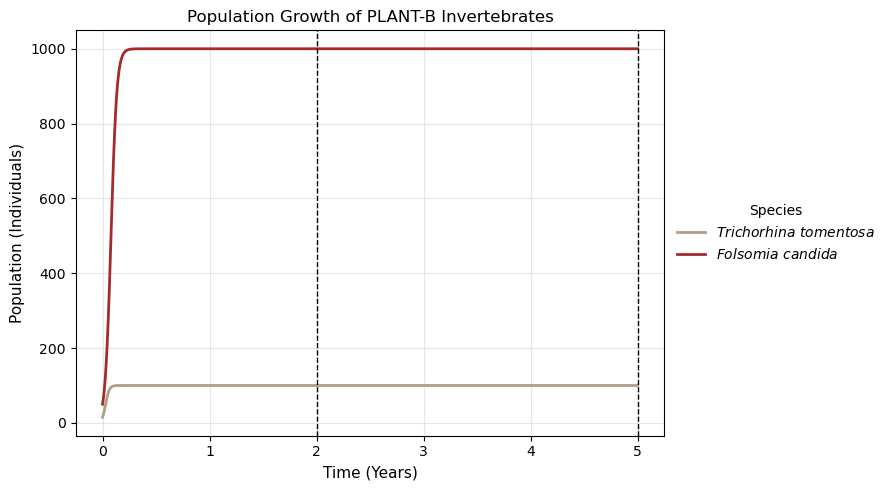

In [15]:
# Give the timeframe (in days)
total_days = 365 * 5 # Five years in total
t = np.arange(total_days)

# Define population parameters for the two invertebrates:
# Isopod population parameters
isopods = 15 # Starting number of isopod individuals
isopod_carrying_capacity = 100 # Estimated isopod carrying capacity for the terrarium
isopod_fecundity = 0.164 # Average daily fecundity (by eggs laid) of a close relative (Heeley, 1941)
isopod_mortality = 0.0011 # Calculated from an assumed average lifespan of 2.5 years

# Model the isopod population growth over time
isopod_growth_rate = isopod_fecundity - isopod_mortality # Define the daily growth rate for the isopods
isopod_population = isopod_carrying_capacity / (1 + ((isopod_carrying_capacity - isopods) / isopods) * np.exp(-isopod_growth_rate * t))

# Springtail population parameters
springtails = 50 # Starting number of springtail individuals
springtail_carrying_capacity = 1000 # Springtail carrying capacity for the terrarium
springtail_fecundity = 0.109 # Average daily fecundity of adult springtails (Xie et al., 2026)
springtail_mortality = 0.00734 # Average daily mortality of the springtails at 21°C (Snider & Butcher, 1973)

# Model the springtail population growth over time
springtail_growth_rate = springtail_fecundity - springtail_mortality # Define the daily growth rate for the springtails
springtail_population = springtail_carrying_capacity / (1 + ((springtail_carrying_capacity - springtails) / springtails) * 
                                                        np.exp(-springtail_growth_rate * t))

# Create a function that plots the invertebrate population growth over five years:
def population_growth_plot(t, isopod_population, springtail_population):
    """
    Parameters:
    t (array): Time values in days across five years
    isopod_population: Growing isopod population count over time
    springtail_population: Growing springtail population count over time

    Returns:
    A line chart that shows the isopod and springtail population growth curves over the five-year timeframe
    """
    # Label the population curves and set their colors
    species_colors = {
        "Trichorhina tomentosa": "#B19C86", # Weathered wood the white dwarf isopod
        # Dark orange for the temperate white springtail
        "Folsomia candida": "#A52A2A" # Reddish-brown for the temperate white springtail
    }

    # Convert the day-based time array to years for the x-axis
    years = t / 365

    # Create the figure
    fig, ax = plt.subplots(figsize=(9, 5))

    # Plot the isopod population growth curve
    ax.plot(
        years,
        isopod_population,
        color=species_colors["Trichorhina tomentosa"], # Ensure the isopod keeps its designated color
        label=r"$\it{Trichorhina\ tomentosa}$", # Italicize the isopod's scientific name
        linewidth=2
    )

    # Plot the springtail population growth curve
    ax.plot(
        years,
        springtail_population,
        color=species_colors["Folsomia candida"], # Ensure the springtail keeps its designated color
        label=r"$\it{Folsomia\ candida}$", # Italicize the springtail's scientific name
        linewidth=2
    )

    # Set the title
    ax.set_title("Population Growth of PLANT-B Invertebrates", fontsize=12)

    # Label the x- and y-axis and set their font size
    ax.set_xlabel("Time (Years)", fontsize=11)
    ax.set_ylabel("Population (Individuals)", fontsize=11)

    # Mark the two- and five-year intervals on the plot
    plt.axvline(2, color='black', linestyle='--', linewidth=1) # For two years
    plt.axvline(5, color='black', linestyle='--', linewidth=1) # For five years

    # Create a legend titled "Species" and anchor it to the right
    ax.legend(title='Species', loc='center left', bbox_to_anchor=(1.0, 0.5), frameon=False)

    # Add gridlines for readability
    ax.grid(True, alpha=0.3)

    # Apply a tight layout
    plt.tight_layout()

    # Save the plot as a png image to the "plots" folder
    plt.savefig(
        os.path.join(plots_dir, "PLANT-B_Invertebrate_Population_Growth_Plot.png"),
        dpi=300,
        bbox_inches="tight"
    )

    # Display the plot
    plt.show()

    # Return the figure and axes
    return fig, ax

# Call the function
fig, ax = population_growth_plot(
    t,
    isopod_population,
    springtail_population
)

In [ ]:
# Plot carbon and nitrogen cycles for the terrarium over 5 years

# Define fixed conditons
whc = 0.60 # Target water holding capacity (WHC) of 60%

# Define population parameters for the three species:
# Moss population parameters
moss_mass = 0.002 * hygrolon_area # Moss mass per cm² = 0.002 g/cm² X 200 cm² = 0.4 g ()
moss_c_uptake_rate = 0.02729 * moss_mass * t # Daily carbon uptake per gram of moss (Mohanasundaram et al., 2023)


# Calculate starting moss carbon (g)
starting_moss_c = moss_mass * (moss_c / 100)

# Calculate starting moss nitrogen (g)
starting_moss_n = moss_mass * (moss_n / 100)

# Isopod population parameters
isopod_mass = 0.01022 # Average mass (g) of a close relative of the isopod (Bílá et al., 2014)
isopod_consumption = 0.0002 # Average daily litter consumption (g) of a close relative of the isopod (Bílá et al., 2014)
isopod_excretion = 

# Calculate starting isopod carbon (g)
starting_isopod_c = isopods * isopod_mass * (isopod_c / 100) 

# Calculate starting isopod nitrogen (g)
starting_isopod_n = isopods * isopod_mass * (isopod_n / 100)



# Springtail population parameters
springtail_mass = 0.00025 # Average mass (g) of a close relative of the springtail
springtail_consumption = 
springtail_excretion = 

# Calculate starting springtail carbon (g)
starting_springtail_c = springtails * springtail_mass * (springtail_c / 100) 

# Calculate starting springtail nitrogen (g)
starting_springtail_n = springtails * springtail_mass * (springtail_n / 100) 



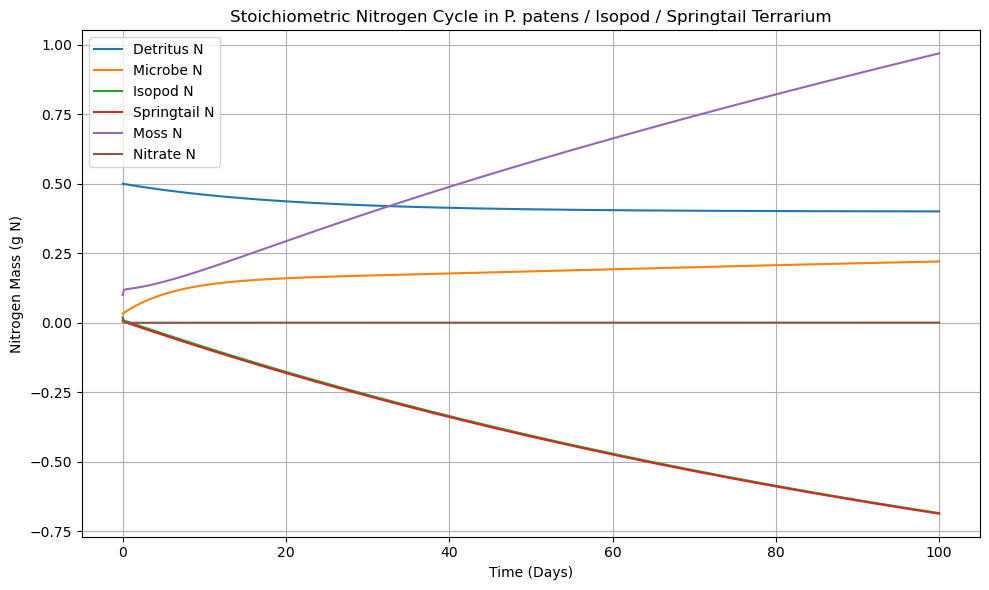

In [ ]:

# --- STOICHIOMETRIC PARAMETERS ---
# C:N ratios (based on typical biological values)
CN_detritus = 25.0
CN_microbe = 6.0
CN_isopod = 10.0
CN_springtail = 10.0
CN_moss = 30.0

# Yield and assimilation efficiencies
Y_microbe = 0.45 
A_isopod = 0.60
A_springtail = 0.60
gross_growth_eff = 0.30 

# Decay/Excretion/Death rates (per day)
m_detritus = 0.05
r_microbes = 0.15
e_isopod = 0.02
e_springtail = 0.02
mort_isopod = 0.01
mort_springtail = 0.01

# Uptake rates
uptake_max = 0.20 # Moss N uptake
d_nitrate = 0.10  # Nitrate loss/denitrification rate

# --- INITIAL POOLS (g N) ---
C_detritus_0 = 12.5
C_microbes_0 = 0.2
C_isopod_0 = 0.1
C_springtail_0 = 0.05
N_moss_0 = 0.1
N_nitrate_0 = 0.02

# Convert to N-pools: N = C / CN_ratio
N_detritus_0 = C_detritus_0 / CN_detritus
N_microbes_0 = C_microbes_0 / CN_microbe
N_isopod_0 = C_isopod_0 / CN_isopod
N_springtail_0 = C_springtail_0 / CN_springtail

y0 = [N_detritus_0, N_microbes_0, N_isopod_0, N_springtail_0, N_moss_0, N_nitrate_0]

# --- SYSTEM OF DIFFERENTIAL EQUATIONS ---
def n_cycle_model(y, t):
    N_det, N_mic, N_iso, N_spr, N_moss, N_nit = y
    
    # Detritus breakdown by microbes
    decomp = m_detritus * N_det
    
    # Microbe uptake of N from detritus and nitrate
    mic_uptake = r_microbes * N_mic
    # Isopod and Springtail consumption
    iso_consume = e_isopod * N_iso
    spr_consume = e_springtail * N_spr
    
    # Flows of Nitrogen
    d_N_det = -decomp + mort_isopod + mort_springtail
    d_N_mic = decomp - mic_uptake - iso_consume 
    d_N_iso = (iso_consume * A_isopod) - (e_isopod * N_iso) - mort_isopod
    d_N_spr = (spr_consume * A_springtail) - (e_springtail * N_spr) - mort_springtail
    
    # Moss N-uptake and Excretion
    moss_uptake = uptake_max * (N_nit / (N_nit + 0.01)) # Monod kinetics
    moss_excr = 0.01 * N_moss
    d_N_moss = moss_uptake - moss_excr
    
    # Nitrogen excretion and nitrate pool
    excreted_N = (iso_consume * (1 - A_isopod)) + (spr_consume * (1 - A_springtail))
    mineralized_N = excreted_N + (r_microbes * N_mic * (1 - Y_microbe)) + moss_excr
    d_N_nit = mineralized_N - moss_uptake - d_nitrate * N_nit
    
    return [d_N_det, d_N_mic, d_N_iso, d_N_spr, d_N_moss, d_N_nit]

# --- SIMULATION ---
time = np.linspace(0, 100, 1000)
results = odeint(n_cycle_model, y0, time)

# --- PLOTTING ---
plt.figure(figsize=(10, 6))
labels = ['Detritus N', 'Microbe N', 'Isopod N', 'Springtail N', 'Moss N', 'Nitrate N']
for i in range(6):
    plt.plot(time, results[:, i], label=labels[i])

plt.title('Stoichiometric Nitrogen Cycle in P. patens / Isopod / Springtail Terrarium')
plt.xlabel('Time (Days)')
plt.ylabel('Nitrogen Mass (g N)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Data Sources

Bílá, K., Moretti, M., de Bello, F., Dias, A. T. C., Pezzatti, G. B., Van Oosten, A. R., & Berg, M. P. (2014). Disentangling community functional components in a litter‐macrodetritivore model system reveals the predominance of the mass ratio hypothesis. *Ecology and Evolution*, *4*(4), 408–416. https://doi.org/10.1002/ece3.941

Boominathan Mohanasundaram, Koley, S., Allen, D. K., & Pandey, S. (2023). *Physcomitrium patens* response to elevated CO2 is flexible and determined by an interaction between sugar and nitrogen availability. *New Phytologist*, *241*(3), 1222–1235. https://doi.org/10.1111/nph.19348

Heeley, W. (1941). Observations on the Life-Histories of some Terrestrial Isopods. *Proceedings of the Zoological Society of London*, *B111*(1–2), 79–149. https://doi.org/10.1111/j.1469-7998.1941.tb00044.x

Snider, R. M., & Butcher, J. W. (1973). The Life History of *Folsomia Candida* (Willem) (Collembola: Isotomidae) Relative to Temperature. *The Great Lakes Entomologist*, *6*(4), 97-106. https://doi.org/10.22543/0090-0222.1187

Xie, L., Duan, X., Norouzi, S., de Jonge, L. W., & Topping, C. J. (2026). Integrating spatial and environmental stressors in a population model of *Folsomia candida* (Collembola, Isotomidae): a Formal Model within ALMaSS framework. *Agricultural and Environmental Modelling*, *8*, e184962. https://doi.org/10.3897/aem.8.184962

